In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('../data/worldbank_pib.csv')
df['anio'] = df['anio'].astype(int)
co = df[df['pais_codigo'] == 'CO'].copy()

print(f"Dataset: {df.shape}")
print(f"Colombia: {co.shape}")
df.head()

Dataset: (168, 13)
Colombia: (24, 13)


,pais_codigo,pais_nombre,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib,fecha_extraccion,region,es_colombia
0,AR,Argentina,2000,2.842038e+11,-0.788999,7637.014892,NaN,15.000,10.986375,11.636070,2026-03-05T21:35:13.377882,América Latina,False
1,AR,Argentina,2001,2.686968e+11,-4.408840,7141.475077,NaN,17.320,11.579008,10.273247,2026-03-05T21:35:13.377882,América Latina,False
2,AR,Argentina,2002,9.772400e+10,-10.894485,2569.699635,NaN,19.590,28.382597,13.370127,2026-03-05T21:35:13.377882,América Latina,False
3,AR,Argentina,2003,1.275870e+11,8.837041,3320.477751,NaN,15.360,25.930943,14.713805,2026-03-05T21:35:13.377882,América Latina,False
4,AR,Argentina,2004,1.646579e+11,9.029573,4242.020991,NaN,13.522,23.847619,16.845027,2026-03-05T21:35:13.377882,América Latina,False


In [2]:
print("=== Info general ===")
print(df.info())
print("\n=== Valores nulos ===")
print(df.isnull().sum())
print("\n=== Estadísticas descriptivas ===")
df.describe().round(2)

=== Info general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pais_codigo            168 non-null    object 
 1   pais_nombre            168 non-null    object 
 2   anio                   168 non-null    int64  
 3   pib_usd                144 non-null    float64
 4   crecimiento_pib_pct    168 non-null    float64
 5   pib_per_capita_usd     168 non-null    float64
 6   inflacion_pct          150 non-null    float64
 7   desempleo_pct          168 non-null    float64
 8   exportaciones_pct_pib  168 non-null    float64
 9   importaciones_pct_pib  168 non-null    float64
 10  fecha_extraccion       168 non-null    object 
 11  region                 168 non-null    object 
 12  es_colombia            168 non-null    bool   
dtypes: bool(1), float64(7), int64(1), object(4)
memory usage: 16.0+ KB
None

=== Valores nulo

,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib
count,168.00,1.440000e+02,168.00,168.00,150.00,168.00,168.00,168.00
mean,2011.50,3.157486e+12,2.77,14695.12,6.71,7.73,21.42,21.61
std,6.94,6.408322e+12,3.90,16772.12,13.72,3.56,9.15,7.97
min,2000.00,5.174475e+10,-10.93,1929.57,-0.36,2.63,9.04,10.27
25%,2005.75,2.002740e+11,1.35,6196.11,2.81,4.69,13.58,14.72
50%,2011.50,3.280041e+11,2.91,8874.80,3.77,7.54,18.28,19.92
75%,2017.25,1.131187e+12,4.97,13185.27,5.87,9.99,28.34,27.90
max,2023.00,2.729217e+13,13.36,81032.26,133.49,20.52,45.13,45.87


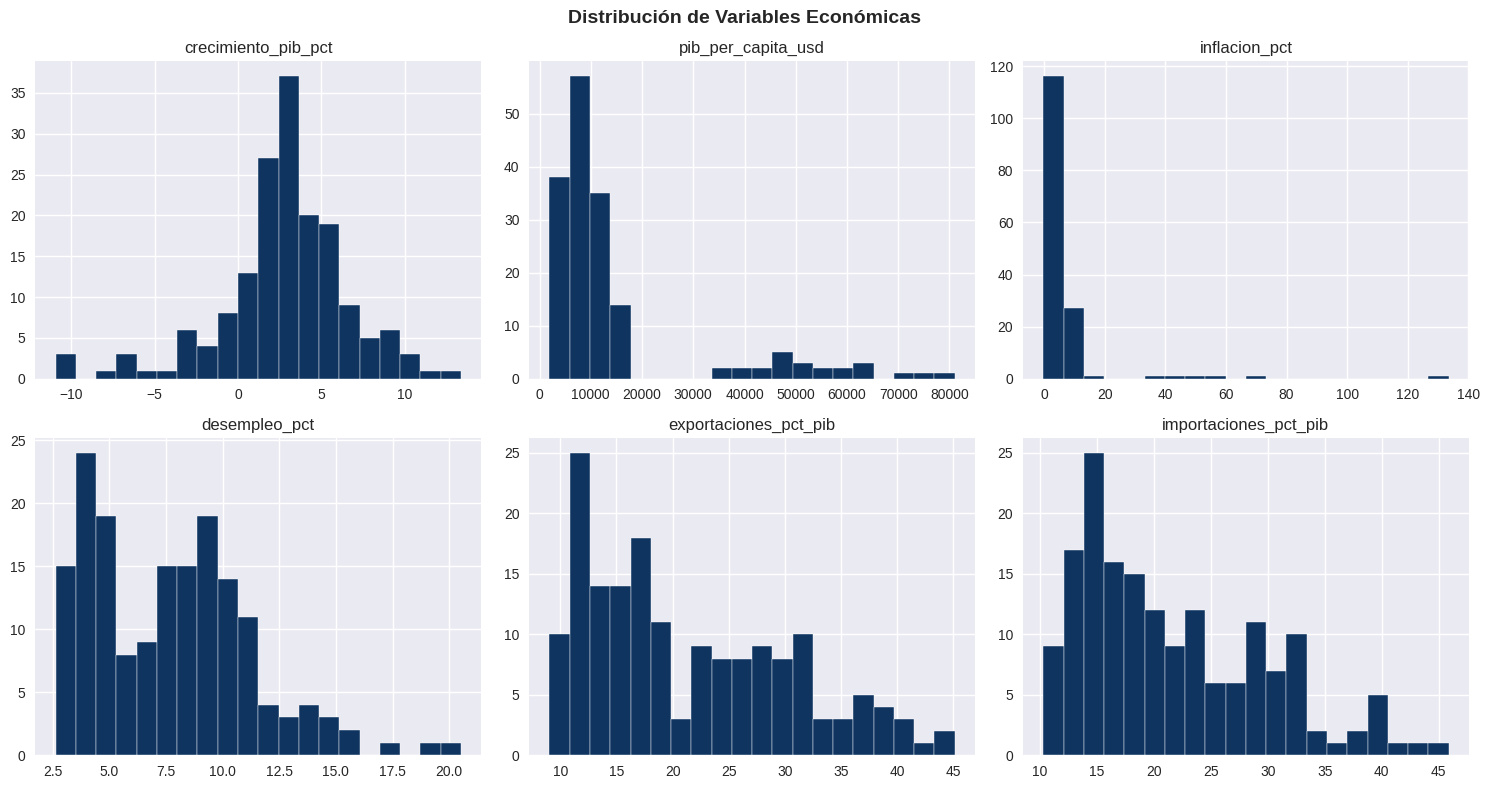

✅ Gráfica 1: Histogramas


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['crecimiento_pib_pct', 'pib_per_capita_usd', 'inflacion_pct',
        'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']
for ax, col in zip(axes.flatten(), cols):
    df[col].dropna().hist(bins=20, ax=ax, color='#0f3460', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución de Variables Económicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 1: Histogramas")

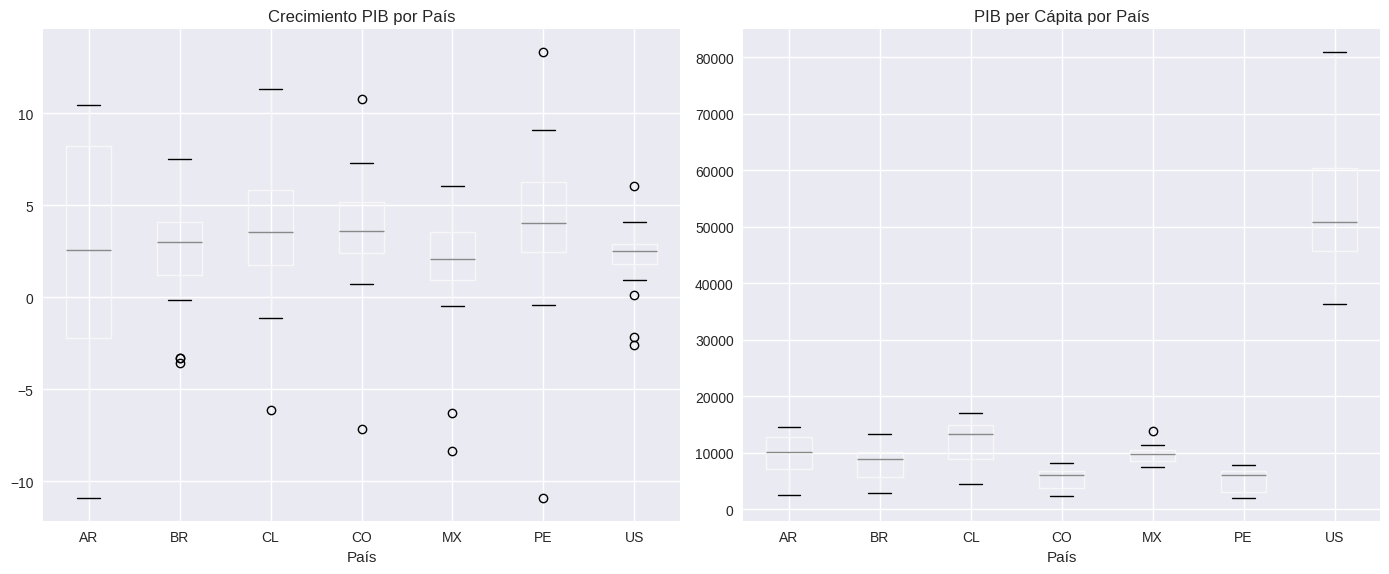

✅ Gráfica 2: Boxplots


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df.boxplot(column='crecimiento_pib_pct', by='pais_codigo', ax=axes[0])
axes[0].set_title('Crecimiento PIB por País')
axes[0].set_xlabel('País')
df.boxplot(column='pib_per_capita_usd', by='pais_codigo', ax=axes[1])
axes[1].set_title('PIB per Cápita por País')
axes[1].set_xlabel('País')
plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 2: Boxplots")

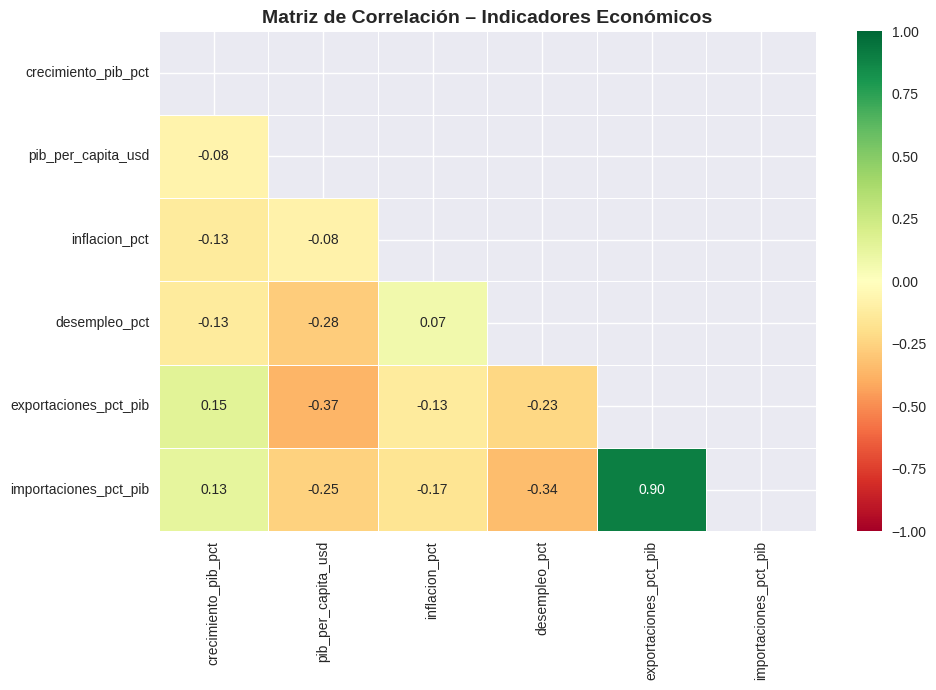

✅ Gráfica 3: Correlaciones


In [5]:
cols_num = ['crecimiento_pib_pct', 'pib_per_capita_usd', 'inflacion_pct',
            'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']
corr = df[cols_num].corr()
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación – Indicadores Económicos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 3: Correlaciones")

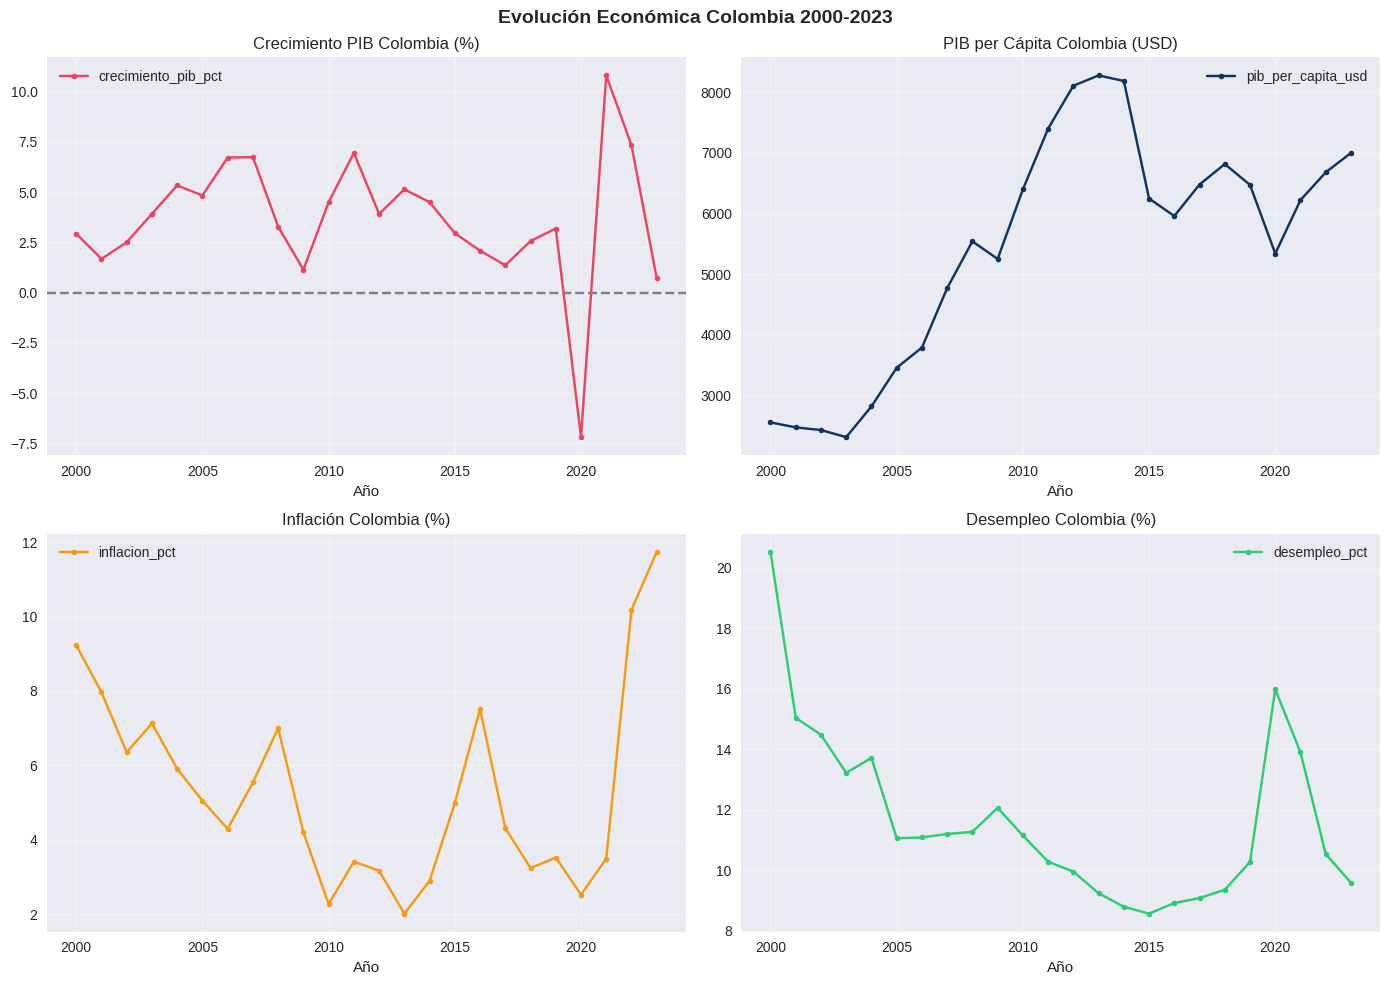

✅ Gráfica 4: Series temporales Colombia


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
co.plot(x='anio', y='crecimiento_pib_pct', ax=axes[0,0], color='#e94560', marker='o', ms=4)
axes[0,0].set_title('Crecimiento PIB Colombia (%)'); axes[0,0].axhline(0, color='gray', ls='--')
co.plot(x='anio', y='pib_per_capita_usd', ax=axes[0,1], color='#0f3460', marker='o', ms=4)
axes[0,1].set_title('PIB per Cápita Colombia (USD)')
co.plot(x='anio', y='inflacion_pct', ax=axes[1,0], color='#f39c12', marker='o', ms=4)
axes[1,0].set_title('Inflación Colombia (%)')
co.plot(x='anio', y='desempleo_pct', ax=axes[1,1], color='#2ecc71', marker='o', ms=4)
axes[1,1].set_title('Desempleo Colombia (%)')
for ax in axes.flatten():
    ax.set_xlabel('Año'); ax.grid(alpha=0.3)
plt.suptitle('Evolución Económica Colombia 2000-2023', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('serie_temporal_co.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 4: Series temporales Colombia")

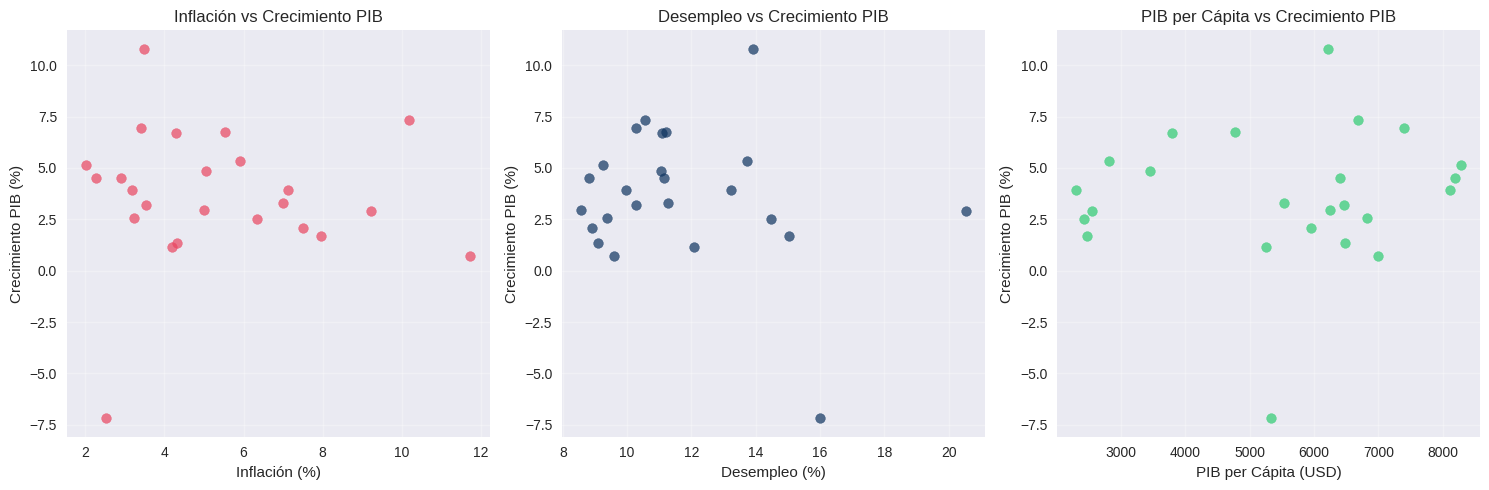

✅ Gráfica 5: Scatter plots


In [7]:
co_clean = co.dropna(subset=['crecimiento_pib_pct', 'inflacion_pct',
                               'desempleo_pct', 'pib_per_capita_usd'])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(co_clean['inflacion_pct'], co_clean['crecimiento_pib_pct'],
                color='#e94560', alpha=0.7)
axes[0].set_xlabel('Inflación (%)'); axes[0].set_ylabel('Crecimiento PIB (%)')
axes[0].set_title('Inflación vs Crecimiento PIB')
axes[1].scatter(co_clean['desempleo_pct'], co_clean['crecimiento_pib_pct'],
                color='#0f3460', alpha=0.7)
axes[1].set_xlabel('Desempleo (%)'); axes[1].set_ylabel('Crecimiento PIB (%)')
axes[1].set_title('Desempleo vs Crecimiento PIB')
axes[2].scatter(co_clean['pib_per_capita_usd'], co_clean['crecimiento_pib_pct'],
                color='#2ecc71', alpha=0.7)
axes[2].set_xlabel('PIB per Cápita (USD)'); axes[2].set_ylabel('Crecimiento PIB (%)')
axes[2].set_title('PIB per Cápita vs Crecimiento PIB')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 5: Scatter plots")

In [8]:
co_reg = co.dropna(subset=['anio', 'pib_per_capita_usd'])
X = co_reg[['anio']].values
y = co_reg['pib_per_capita_usd'].values

modelo = LinearRegression().fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred

ss_res = np.sum(residuos**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot
mae = np.mean(np.abs(residuos))
rmse = np.sqrt(np.mean(residuos**2))

print("=== Regresión Lineal Simple: Año → PIB per Cápita Colombia ===")
print(f"Coeficiente (pendiente): {modelo.coef_[0]:,.2f} USD/año")
print(f"Intercepto: {modelo.intercept_:,.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

años_futuro = np.array([[2024],[2025],[2026],[2027]])
pred_futuro = modelo.predict(años_futuro)
print("\nPredicciones futuras:")
for a, p in zip(años_futuro.flatten(), pred_futuro):
    print(f"  {a}: ${p:,.0f} USD per cápita")

=== Regresión Lineal Simple: Año → PIB per Cápita Colombia ===
Coeficiente (pendiente): 208.23 USD/año
Intercepto: -413,404.03
R²:   0.5728
MAE:  $1,000.52
RMSE: $1,244.78

Predicciones futuras:
  2024: $8,061 USD per cápita
  2025: $8,269 USD per cápita
  2026: $8,477 USD per cápita
  2027: $8,686 USD per cápita


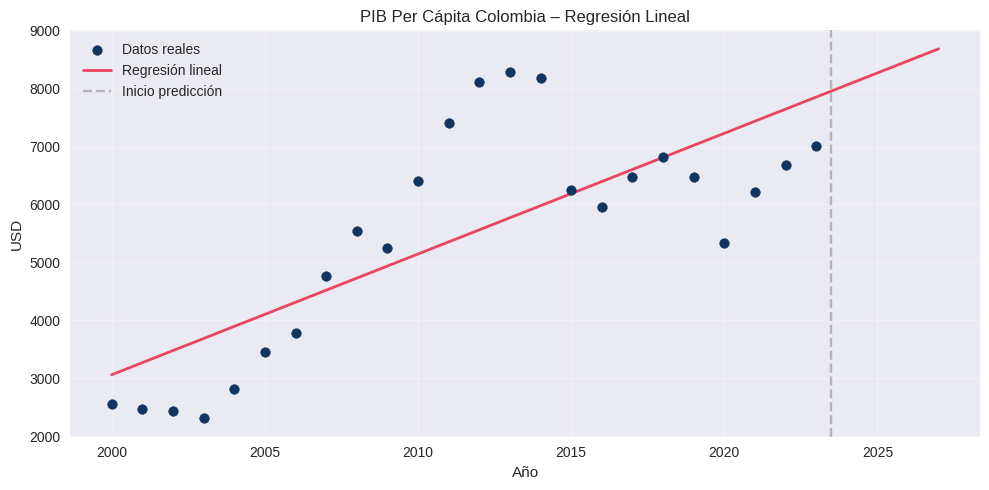

✅ Gráfica 6: Regresión simple


In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(co_reg['anio'], y, color='#0f3460', label='Datos reales', zorder=5)
años_linea = np.arange(2000, 2028).reshape(-1,1)
plt.plot(años_linea, modelo.predict(años_linea), color='#e94560', lw=2, label='Regresión lineal')
plt.axvline(x=2023.5, color='gray', ls='--', alpha=0.5, label='Inicio predicción')
plt.xlabel('Año'); plt.ylabel('USD'); plt.title('PIB Per Cápita Colombia – Regresión Lineal')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('regresion_simple.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 6: Regresión simple")

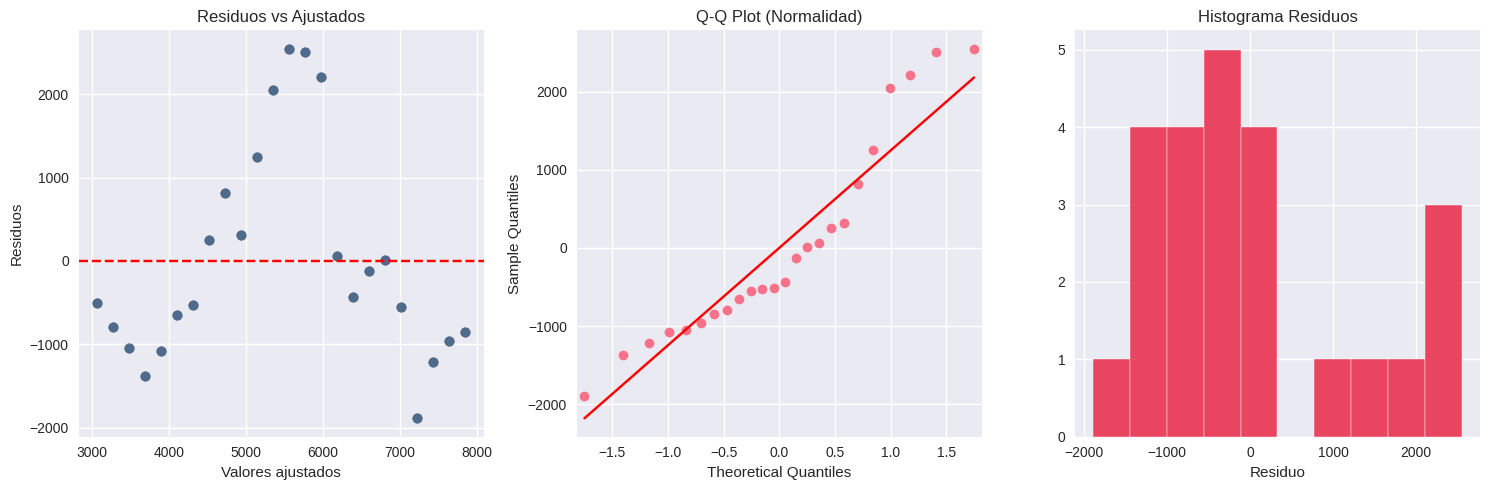

✅ Gráfica 7: Diagnóstico de residuos


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(y_pred, residuos, color='#0f3460', alpha=0.7)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados')
sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Normalidad)')
axes[2].hist(residuos, bins=10, color='#e94560', edgecolor='white')
axes[2].set_xlabel('Residuo'); axes[2].set_title('Histograma Residuos')
plt.tight_layout()
plt.savefig('diagnostico_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 7: Diagnóstico de residuos")

In [11]:
stat_sw, p_sw = stats.shapiro(residuos)
dw = durbin_watson(residuos)
print("=== Diagnósticos Estadísticos ===")
print(f"\n📊 Test Shapiro-Wilk (normalidad residuos):")
print(f"   Estadístico: {stat_sw:.4f} | p-valor: {p_sw:.4f}")
print(f"   {'✅ Normal (p>0.05)' if p_sw > 0.05 else '⚠️  No normal (p<=0.05)'}")
print(f"\n📊 Durbin-Watson (autocorrelación):")
print(f"   Estadístico: {dw:.4f}")
print(f"   {'✅ Sin autocorrelación (1.5-2.5)' if 1.5 < dw < 2.5 else '⚠️  Posible autocorrelación'}")

=== Diagnósticos Estadísticos ===

📊 Test Shapiro-Wilk (normalidad residuos):
   Estadístico: 0.8968 | p-valor: 0.0184
   ⚠️  No normal (p<=0.05)

📊 Durbin-Watson (autocorrelación):
   Estadístico: 0.3002
   ⚠️  Posible autocorrelación


In [12]:
cols_X = ['inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib']
co_mult = co.dropna(subset=['crecimiento_pib_pct'] + cols_X)
X_mult = co_mult[cols_X].values
y_mult = co_mult['crecimiento_pib_pct'].values

X_sm = sm.add_constant(X_mult)
modelo_mult = sm.OLS(y_mult, X_sm).fit()
print(modelo_mult.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     3.657
Date:                Mon, 13 Apr 2026   Prob (F-statistic):             0.0299
Time:                        16:43:06   Log-Likelihood:                -56.940
No. Observations:                  24   AIC:                             121.9
Df Residuals:                      20   BIC:                             126.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.7349      8.090     -2.192      0.0

In [13]:
print("=== VIF – Multicolinealidad ===")
vif_data = pd.DataFrame()
vif_data['Variable'] = cols_X
vif_data['VIF'] = [variance_inflation_factor(X_mult, i) for i in range(X_mult.shape[1])]
vif_data['Interpretación'] = vif_data['VIF'].apply(
    lambda v: '✅ OK' if v < 5 else ('⚠️  Moderado' if v < 10 else '❌ Alto'))
print(vif_data.to_string(index=False))

=== VIF – Multicolinealidad ===
             Variable       VIF Interpretación
        inflacion_pct  5.994584   ⚠️  Moderado
        desempleo_pct 14.387060         ❌ Alto
exportaciones_pct_pib 14.713131         ❌ Alto


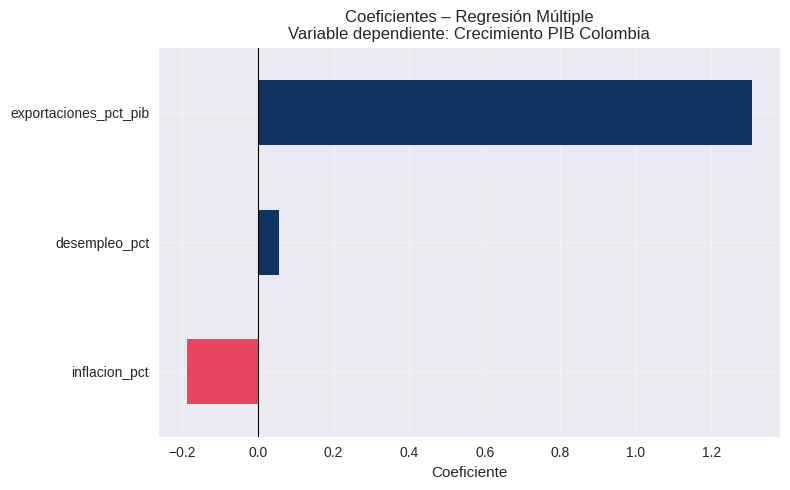

✅ Gráfica 8: Coeficientes regresión múltiple


In [14]:
coefs = pd.Series(modelo_mult.params[1:], index=cols_X)
plt.figure(figsize=(8, 5))
coefs.plot(kind='barh', color=['#e94560' if c < 0 else '#0f3460' for c in coefs])
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes – Regresión Múltiple\nVariable dependiente: Crecimiento PIB Colombia')
plt.xlabel('Coeficiente')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('coeficientes_mult.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 8: Coeficientes regresión múltiple")

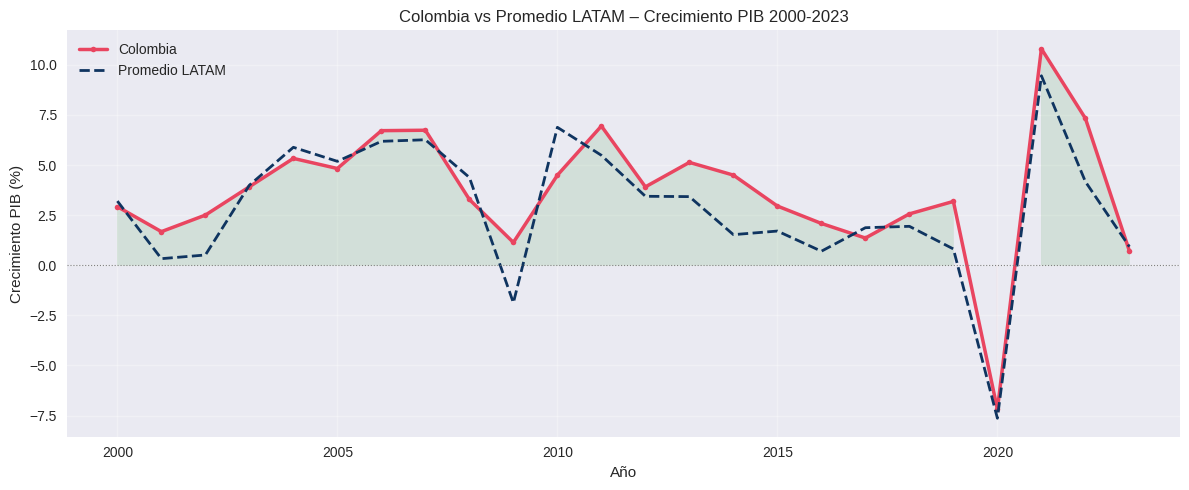

✅ Gráfica 9: Colombia vs LATAM


In [15]:
latam = df[df['region']=='América Latina'].groupby('anio')['crecimiento_pib_pct'].mean()
plt.figure(figsize=(12, 5))
plt.plot(co['anio'], co['crecimiento_pib_pct'], color='#e94560', lw=2.5,
         marker='o', ms=4, label='Colombia')
plt.plot(latam.index, latam.values, color='#0f3460', lw=2, ls='--', label='Promedio LATAM')
plt.axhline(0, color='gray', ls=':', lw=0.8)
plt.fill_between(co['anio'], co['crecimiento_pib_pct'], 0,
                  where=(co['crecimiento_pib_pct']>0), alpha=0.1, color='green')
plt.fill_between(co['anio'], co['crecimiento_pib_pct'], 0,
                  where=(co['crecimiento_pib_pct']<0), alpha=0.1, color='red')
plt.xlabel('Año'); plt.ylabel('Crecimiento PIB (%)'); plt.legend()
plt.title('Colombia vs Promedio LATAM – Crecimiento PIB 2000-2023')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('co_vs_latam.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 9: Colombia vs LATAM")

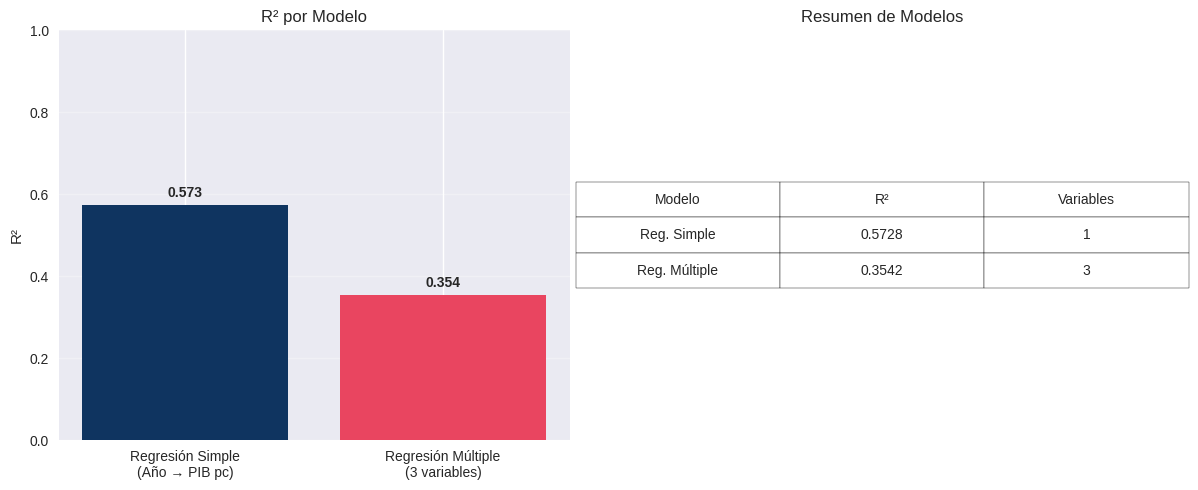

✅ Gráfica 10: Resumen métricas

🎉 Análisis completo — 10 gráficas generadas


In [16]:
metricas = {
    'Regresión Simple\n(Año → PIB pc)': {'R²': r2, 'MAE_norm': mae/y.mean()},
}
r2_mult = modelo_mult.rsquared
mae_mult = np.mean(np.abs(modelo_mult.resid))
metricas['Regresión Múltiple\n(3 variables)'] = {'R²': r2_mult, 'MAE_norm': mae_mult/y_mult.mean()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
nombres = list(metricas.keys())
r2_vals = [metricas[m]['R²'] for m in nombres]
axes[0].bar(nombres, r2_vals, color=['#0f3460', '#e94560'])
axes[0].set_ylim(0, 1); axes[0].set_ylabel('R²')
axes[0].set_title('R² por Modelo'); axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

resumen = pd.DataFrame({
    'Modelo': ['Reg. Simple', 'Reg. Múltiple'],
    'R²': [round(r2, 4), round(r2_mult, 4)],
    'Variables': [1, 3]
})
axes[1].axis('off')
tabla = axes[1].table(cellText=resumen.values, colLabels=resumen.columns,
                       loc='center', cellLoc='center')
tabla.scale(1.2, 2)
axes[1].set_title('Resumen de Modelos')
plt.tight_layout()
plt.savefig('resumen_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 10: Resumen métricas")
print("\n🎉 Análisis completo — 10 gráficas generadas")